In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_csv("../../data/raw/Consumer_Shopping_Trends_2026.csv")

In [4]:
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

Rows: 11789
Columns: 25


In [5]:
df.head()

,age,monthly_income,daily_internet_hours,smartphone_usage_years,social_media_hours,online_payment_trust_score,tech_savvy_score,monthly_online_orders,monthly_store_visits,avg_online_spend,...,free_return_importance,product_availability_online,impulse_buying_score,need_touch_feel_score,brand_loyalty_score,environmental_awareness,time_pressure_level,gender,city_tier,shopping_preference
0,56,221111,6.5,12,0.7,1,6,16,16,28551,...,7,7,1,3,6,5,2,Other,Tier 3,Store
1,69,96029,8.2,13,2.7,6,9,14,1,124056,...,3,4,9,6,8,1,7,Male,Tier 3,Hybrid
2,46,19055,6.4,4,2.1,10,8,2,0,81939,...,4,10,1,1,3,3,3,Female,Tier 3,Store
3,32,53170,6.4,11,0.7,2,10,20,3,35901,...,10,2,4,8,2,6,6,Female,Tier 1,Store
4,60,244016,6.0,5,0.7,2,5,18,16,131971,...,2,5,8,9,7,1,6,Male,Tier 3,Store


In [7]:
df.dtypes


age                              int64
monthly_income                   int64
daily_internet_hours           float64
smartphone_usage_years           int64
social_media_hours             float64
online_payment_trust_score       int64
tech_savvy_score                 int64
monthly_online_orders            int64
monthly_store_visits             int64
avg_online_spend                 int64
avg_store_spend                  int64
discount_sensitivity             int64
return_frequency                 int64
avg_delivery_days                int64
delivery_fee_sensitivity         int64
free_return_importance           int64
product_availability_online      int64
impulse_buying_score             int64
need_touch_feel_score            int64
brand_loyalty_score              int64
environmental_awareness          int64
time_pressure_level              int64
gender                          object
city_tier                       object
shopping_preference             object
dtype: object

In [9]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({'missing count': missing, 'missing %': missing_pct})

,missing count,missing %
age,0,0.0
monthly_income,0,0.0
daily_internet_hours,0,0.0
smartphone_usage_years,0,0.0
social_media_hours,0,0.0
online_payment_trust_score,0,0.0
tech_savvy_score,0,0.0
monthly_online_orders,0,0.0
monthly_store_visits,0,0.0
avg_online_spend,0,0.0


In [10]:
print(f"Duplicate rows: {df.duplicated().sum()}")


Duplicate rows: 0


In [11]:
df.describe().round(2)


,age,monthly_income,daily_internet_hours,smartphone_usage_years,social_media_hours,online_payment_trust_score,tech_savvy_score,monthly_online_orders,monthly_store_visits,avg_online_spend,...,return_frequency,avg_delivery_days,delivery_fee_sensitivity,free_return_importance,product_availability_online,impulse_buying_score,need_touch_feel_score,brand_loyalty_score,environmental_awareness,time_pressure_level
count,11789.00,11789.00,11789.00,11789.00,11789.00,11789.00,11789.00,11789.00,11789.00,11789.00,...,11789.00,11789.0,11789.00,11789.00,11789.00,11789.00,11789.00,11789.00,11789.00,11789.00
mean,48.73,131704.28,6.01,7.60,2.51,5.50,5.53,24.68,9.48,74554.93,...,4.47,4.0,5.47,5.46,5.52,5.49,5.49,5.53,5.45,5.50
std,17.90,68120.73,1.98,4.01,1.26,2.88,2.89,14.43,5.73,43167.13,...,2.89,2.0,2.87,2.88,2.87,2.88,2.88,2.85,2.87,2.88
min,18.00,15005.00,1.00,1.00,0.00,1.00,1.00,0.00,0.00,523.00,...,0.00,1.0,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
25%,33.00,72450.00,4.60,4.00,1.60,3.00,3.00,12.00,5.00,36797.00,...,2.00,2.0,3.00,3.00,3.00,3.00,3.00,3.00,3.00,3.00
50%,49.00,131916.00,6.00,8.00,2.50,5.00,6.00,25.00,9.00,74859.00,...,4.00,4.0,5.00,5.00,6.00,5.00,5.00,6.00,5.00,6.00
75%,64.00,190505.00,7.40,11.00,3.40,8.00,8.00,37.00,14.00,112134.00,...,7.00,6.0,8.00,8.00,8.00,8.00,8.00,8.00,8.00,8.00
max,79.00,249989.00,12.00,14.00,6.00,10.00,10.00,49.00,19.00,149996.00,...,9.00,7.0,10.00,10.00,10.00,10.00,10.00,10.00,10.00,10.00


Age goes from 18 to 79, mean 48. Realistic adult consumer range, no weird values like 0 or 200. ✅
Monthly income goes from 1,505 to 249,989, mean 131,704. Wide range which is good — captures different economic profiles. ✅
All the score columns (trust, tech_savvy, impulse_buying etc.) go from 0 or 1 to 10, mean around 5.5. They're well distributed and centered. ✅
Monthly online orders goes 0 to 49, mean 24. Some people order 0 times — those are likely pure in-store customers. 

 ### Unique values in categorical columns.

In [13]:
for col in ['gender', 'city_tier', 'shopping_preference']:
    
    print(df[col].value_counts())

gender
Male      3966
Female    3931
Other     3892
Name: count, dtype: int64
city_tier
Tier 1    3982
Tier 3    3949
Tier 2    3858
Name: count, dtype: int64
shopping_preference
Store     10244
Online     1176
Hybrid      369
Name: count, dtype: int64


## 📊 Cell 8 — Key Findings: Categorical Columns

### Gender
Almost perfectly balanced across all three categories (Male: 3,966 / Female: 3,931 / Other: 3,892).
This suggests the dataset is simulated. No gender bias to worry about. ✅

### City Tier
Also evenly distributed (Tier 1: 3,982 / Tier 2: 3,858 / Tier 3: 3,949).
No geographic bias in the sample. ✅

### 🚨 Shopping Preference — Class Imbalance Detected

| Preference | Count  | Share |
|------------|--------|-------|
| Store      | 10,244 | 86.9% |
| Online     |  1,176 |  9.9% |
| Hybrid     |    369 |  3.1% |

**This is a critical finding.**
The target variable is heavily imbalanced — 87% of customers prefer in-store shopping.

A naive model trained on this data will simply predict "Store" for every customer
and achieve 87% accuracy while being completely useless in practice.
It will never learn what makes a customer shop online or adopt a hybrid approach.

**Impact on modeling:**
- Standard accuracy is a misleading metric here
- We must use F1-score, precision, and recall per class instead
- We will apply class balancing techniques in the Feature Engineering phase (SMOTE or class_weight)



### Cell 9 — target distribution visualization.

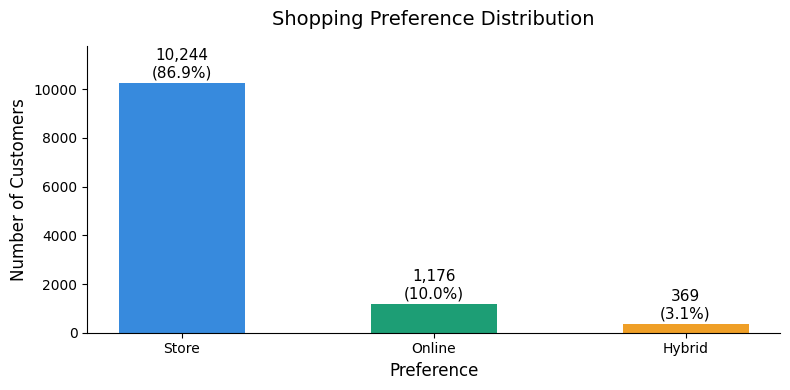

In [14]:
fig, ax = plt.subplots(figsize=(8, 4))

colors = ['#378ADD', '#1D9E75', '#EF9F27']
shopping_counts = df['shopping_preference'].value_counts()

bars = ax.bar(shopping_counts.index, shopping_counts.values, color=colors, width=0.5)

for bar, count in zip(bars, shopping_counts.values):
    pct = count / len(df) * 100
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
            f'{count:,}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=11)

ax.set_title('Shopping Preference Distribution', fontsize=14, pad=15)
ax.set_xlabel('Preference', fontsize=12)
ax.set_ylabel('Number of Customers', fontsize=12)
ax.set_ylim(0, max(shopping_counts.values) * 1.15)
sns.despine()

plt.tight_layout()
plt.savefig('../../docs/target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## ✅ Notebook 01 — Summary & Next Steps

### What we confirmed
- Dataset: 11,789 customers × 25 columns
- No missing values, no duplicates — data is clean
- All column types are correct (no fixes needed)
- Scores range 0–10, age 18–79, income 1.5K–250K — all realistic
- Gender and city tier are perfectly balanced

### Critical finding
- Target variable `shopping_preference` is heavily imbalanced
- Store: 86.9% / Online: 10.0% / Hybrid: 3.1%
- We will NOT use accuracy as our metric — F1-score per class instead
- Class balancing required before modeling (SMOTE or class_weight)

### Next notebook
`02_distributions.ipynb` — deep dive into every feature's distribution,
spot outliers, and understand the shape of the data before visualization.